# L4 Vertebra Detection & BMD Pipeline
## U-Net + Curved Spine Midline (DP Tracking) Edition

### 전체 파이프라인
```
DICOM
 └─► 전처리 (CLAHE)
      └─► Curved Midline Detection  ← [NEW] 척추 기울기/휨 대응
           ├─ Bidirectional DP Tracking  (anchor→위/아래)
           ├─ Gaussian Smoothing
           └─ Row별 Spine X 계산
                └─► Curved Strip → Vertebra 피크 탐지
                     └─► Iliac Crest 랜드마크 → L4 위치
                          ├─► U-Net Segmentation (L1~L5 boundary)
                          ├─► L4 ROI 추출 & 시각화
                          └─► BMD T-Score 측정 (ResNet-18 회귀)
```

> ⚠️ 스크리닝 지표 — 임상 진단은 전문의 판독 필요


## Step 0: 패키지 설치

In [31]:
import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable,'-m','pip','install',pkg,
                    '--break-system-packages','-q'], capture_output=True)

for p in ['pydicom','scikit-image','scipy','matplotlib',
          'numpy','pandas','tqdm','opencv-python-headless',
          'scikit-learn']:
    pip(p)

pip('torch'); pip('torchvision')
print("packages ready")


packages ready


In [32]:
import os, glob, json, warnings, csv
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import pydicom, cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from skimage import exposure
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import gaussian_filter1d

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
plt.rcParams['figure.dpi'] = 110


Device: cpu


## Step 1: 설정

In [33]:

DICOM_FILE = "./dataset-dcm/train/gather/1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm"
DATASET_ROOT = "./dataset"
LABEL_CSV    = "./dataset/labels.csv"
OUTPUT_DIR   = "./bmd_output"
MODEL_DIR    = os.path.join(OUTPUT_DIR, "models")
RESULT_DIR   = os.path.join(OUTPUT_DIR, "results")
for d in [OUTPUT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

CFG = {
    # 이미지
    'img_size':         256,
    'roi_size':         64,
    # 훈련
    'batch_size':       8,
    'num_epochs':       50,
    'lr':               1e-4,
    'weight_decay':     1e-4,
    'early_stop':       10,
    'train_ratio':      0.70,
    'val_ratio':        0.15,
    # Midline 탐지
    'midline_search_x': (0.28, 0.62),   # X 탐색 범위 (이미지 너비 비율)
    'midline_row_range':(0.08, 0.66),   # row 탐색 범위
    'midline_window_w': 16,             # 슬라이딩 윈도우 너비
    'midline_max_step': 5,              # DP 최대 이동 px
    'midline_sigma':    6.0,            # Gaussian smoothing sigma
    # 척추체 탐지
    'strip_width':      28,             # 척추 strip 반폭
    'min_vert_dist':    12,             # 최소 척추체 간격
    'iliac_search_y':   (0.40, 0.60),   # 장골능 탐색 범위
    # BMD 기준값 (phantom calibration 필요)
    'ref_young_mean':   19500.0,
    'ref_young_std':    1500.0,
    'ref_age_mean':     18500.0,
    'ref_age_std':      2000.0,
}
print("Config OK")


Config OK


## Step 2: DICOM 로딩 & 전처리

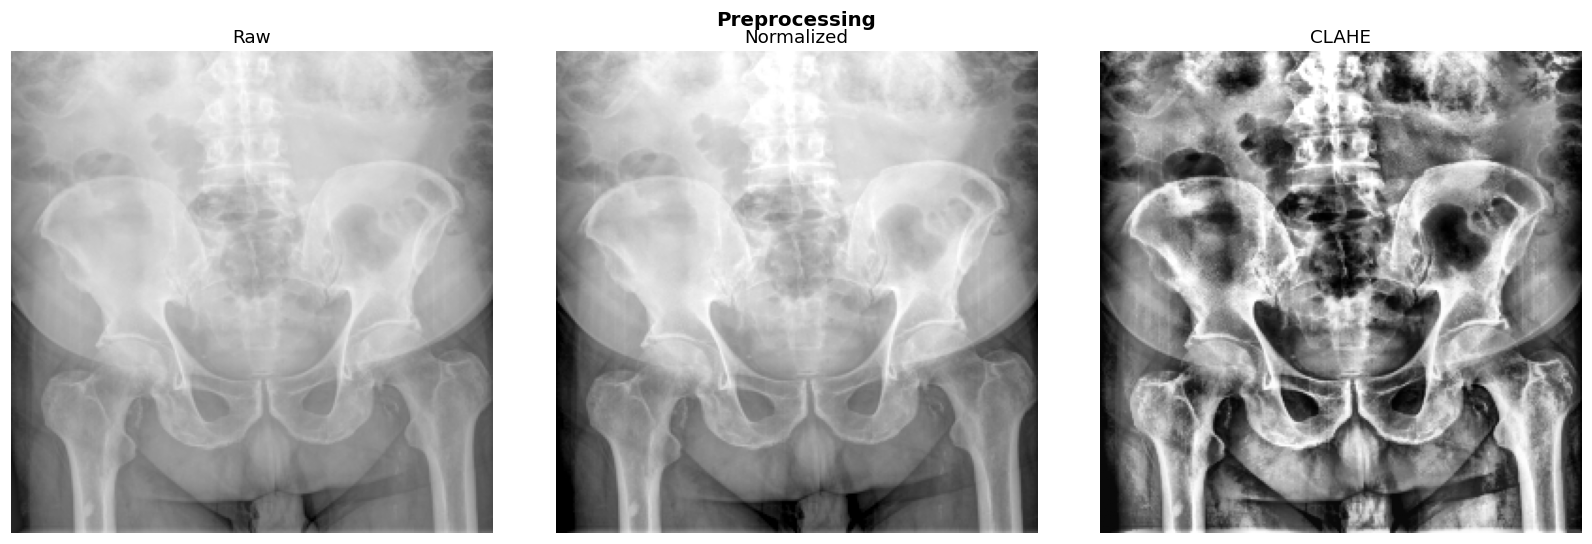

Image: 256x256 | Pixel spacing: ['0.1', '0.1']


In [34]:
def load_dicom(path):
    dcm = pydicom.dcmread(path, force=True)
    arr = dcm.pixel_array.astype(np.float64)
    slope     = float(getattr(dcm,'RescaleSlope',    1.0))
    intercept = float(getattr(dcm,'RescaleIntercept',0.0))
    arr = arr * slope + intercept
    if str(getattr(dcm,'PhotometricInterpretation','MONOCHROME2')).strip()=='MONOCHROME1':
        arr = arr.max() - arr
    meta = {
        'patient_id'   : str(getattr(dcm,'PatientID',   'Unknown')),
        'patient_age'  : str(getattr(dcm,'PatientAge',  'Unknown')),
        'patient_sex'  : str(getattr(dcm,'PatientSex',  'Unknown')),
        'modality'     : str(getattr(dcm,'Modality',    'CR')),
        'study_date'   : str(getattr(dcm,'StudyDate',   '')),
        'pixel_spacing': list(getattr(dcm,'PixelSpacing',[0.1,0.1])),
        'shape'        : arr.shape,
        'filename'     : os.path.basename(path),
    }
    return arr, meta, dcm

def preprocess_xray(arr, target_size=256, clip_limit=0.04):
    h, w    = arr.shape
    mx      = max(h,w)
    padded  = np.zeros((mx,mx), dtype=arr.dtype)
    yo, xo  = (mx-h)//2, (mx-w)//2
    padded[yo:yo+h, xo:xo+w] = arr
    resized = cv2.resize(padded,(target_size,target_size),interpolation=cv2.INTER_LINEAR)
    vmin,vmax = np.percentile(resized,[1,99])
    norm    = np.clip((resized-vmin)/(vmax-vmin+1e-8),0,1)
    clahe   = exposure.equalize_adapthist(norm, clip_limit=clip_limit)
    return norm, clahe.astype(np.float32)

arr, meta, dcm = load_dicom(DICOM_FILE)
norm, clahe    = preprocess_xray(arr, CFG['img_size'])
h, w           = clahe.shape

fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, img, title in zip(axes,[arr,norm,clahe],['Raw','Normalized','CLAHE']):
    ax.imshow(img,cmap='gray'); ax.set_title(title); ax.axis('off')
plt.suptitle('Preprocessing',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/01_preprocess.png',dpi=120,bbox_inches='tight')
plt.show()
print(f"Image: {h}x{w} | Pixel spacing: {meta['pixel_spacing']}")


## Step 3: Curved Spine Midline Detection
### 핵심 알고리즘: Bidirectional DP Tracking

```
기존 방식 (실패):  고정 X 컬럼 → 척추 기울기 무시
새로운 방식:       각 Row 독립 추적 → 척추 곡선 완전 추종

알고리즘:
  1. Anchor 탐지: 가장 신뢰도 높은 row/X 선택 (variance×brightness)
  2. 아래 방향 DP: anchor → 마지막 row (이전 X ± max_step 이내 탐색)
  3. 위 방향 DP:   anchor → 첫 row    (동일 제약)
  4. Gaussian Smoothing: sigma=6 으로 noise 제거
  → 결과: row마다 다른 X = 척추 곡선 추종
```


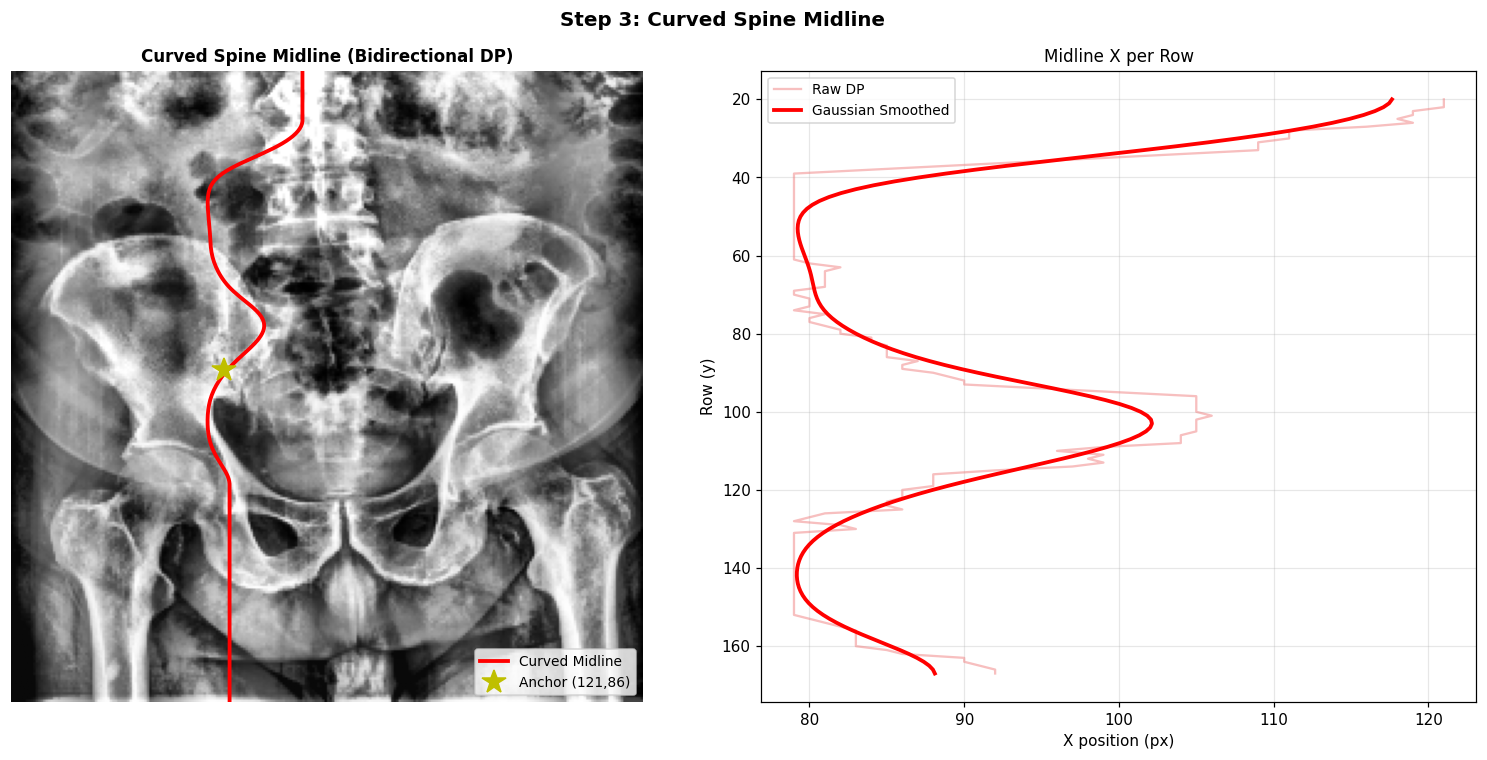

Anchor: row=121, x=86
Midline range: 117.6 ~ 85.2


In [35]:
def detect_curved_midline(clahe, cfg=CFG):
    """
    Bidirectional DP Spine Midline Detection

    Parameters
    ----------
    clahe      : (H,W) float32 전처리 이미지
    cfg        : 설정 dict

    Returns
    -------
    midline_x  : (H,) float array  — 각 row의 척추 중심 X 좌표
    debug_info : dict              — 시각화/디버그용
    """
    h, w    = clahe.shape
    cx0     = int(w * cfg['midline_search_x'][0])
    cx1     = int(w * cfg['midline_search_x'][1])
    r0      = int(h * cfg['midline_row_range'][0])
    r1      = int(h * cfg['midline_row_range'][1])
    ww      = cfg['midline_window_w']
    step    = cfg['midline_max_step']
    sigma   = cfg['midline_sigma']

    # ── Anchor 탐지: 중간 구간(25~55%) 내 가장 뚜렷한 척추 위치 ──
    mid_r0 = max(r0, int(h * 0.25))
    mid_r1 = min(r1, int(h * 0.55))
    best_score, anchor_row, anchor_local = 0.0, (mid_r0+mid_r1)//2, (cx1-cx0)//2

    for r in range(mid_r0, mid_r1):
        seg = clahe[r, cx0:cx1]
        win = np.convolve(seg, np.ones(ww)/ww, mode='same')
        px  = int(np.argmax(win))
        sc  = float(win[px]) * float(np.var(win))
        if sc > best_score:
            best_score, anchor_row, anchor_local = sc, r, px

    # ── 슬라이딩 윈도우 best-X 함수 ──
    def best_local(r, prev_loc):
        seg = clahe[r, cx0:cx1]
        win = np.convolve(seg, np.ones(ww)/ww, mode='same')
        lo  = max(0, prev_loc - step)
        hi  = min(len(win), prev_loc + step + 1)
        return int(np.argmax(win[lo:hi])) + lo

    # ── 양방향 DP 추적 ──
    tracked = {anchor_row: anchor_local}

    prev = anchor_local
    for r in range(anchor_row + 1, r1):            # 아래 방향
        prev = best_local(r, prev); tracked[r] = prev

    prev = anchor_local
    for r in range(anchor_row - 1, r0 - 1, -1):   # 위 방향
        prev = best_local(r, prev); tracked[r] = prev

    rows_arr = np.array(sorted(tracked.keys()))
    xs_abs   = np.array([tracked[r] + cx0 for r in rows_arr], dtype=float)

    # ── Gaussian Smoothing ──
    xs_smooth = gaussian_filter1d(xs_abs, sigma=sigma)

    # ── 전체 이미지에 midline 확장 (범위 밖 = endpoint clamp) ──
    midline_x = np.empty(h, dtype=float)
    for r in range(h):
        if   r <= rows_arr[0]:  midline_x[r] = xs_smooth[0]
        elif r >= rows_arr[-1]: midline_x[r] = xs_smooth[-1]
        else:
            idx = int(np.searchsorted(rows_arr, r, side='left'))
            idx = min(idx, len(xs_smooth)-1)
            midline_x[r] = xs_smooth[idx]

    midline_x = np.clip(midline_x, cx0, cx1).astype(float)

    debug = {
        'rows_tracked' : rows_arr,
        'xs_raw'       : xs_abs,
        'xs_smooth'    : xs_smooth,
        'anchor_row'   : anchor_row,
        'anchor_x'     : anchor_local + cx0,
        'cx0'          : cx0, 'cx1': cx1,
    }
    return midline_x, debug


midline_x, ml_debug = detect_curved_midline(clahe)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
all_rows = np.arange(h)

ax = axes[0]
ax.imshow(clahe, cmap='gray')
ax.plot(midline_x, all_rows, 'r-', lw=2.5, label='Curved Midline')
ax.plot(ml_debug['anchor_x'], ml_debug['anchor_row'],
        'y*', ms=16, zorder=5, label=f"Anchor ({ml_debug['anchor_row']},{ml_debug['anchor_x']})")
ax.legend(fontsize=9, loc='lower right')
ax.set_title('Curved Spine Midline (Bidirectional DP)', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1]
ax.plot(ml_debug['xs_raw'],    ml_debug['rows_tracked'], color='lightcoral', lw=1.5,
        alpha=0.5, label='Raw DP')
ax.plot(ml_debug['xs_smooth'], ml_debug['rows_tracked'], 'r-', lw=2.5,
        label='Gaussian Smoothed')
ax.invert_yaxis()
ax.set_xlabel('X position (px)'); ax.set_ylabel('Row (y)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('Midline X per Row', fontsize=11)

plt.suptitle('Step 3: Curved Spine Midline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/02_curved_midline.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Anchor: row={ml_debug['anchor_row']}, x={ml_debug['anchor_x']}")
print(f"Midline range: {midline_x[20]:.1f} ~ {midline_x[160]:.1f}")


## Step 4: Vertebra Detection (Curved Strip Profile)

In [36]:
def detect_vertebrae_curved(clahe, midline_x, cfg=CFG):
    """
    곡선 midline을 따라 strip을 추출하여 척추체 탐지

    핵심:
    - 각 row에서 midline_x[r] 기준 ±strip_width 범위를 추출
    - Row별 mean → 1D 강도 프로파일 → 피크 탐지
    """
    h, w      = clahe.shape
    sw        = cfg['strip_width']
    r_start   = int(h * cfg['midline_row_range'][0])
    r_end     = int(h * cfg['midline_row_range'][1])

    strip_means = []
    strip_rows  = list(range(r_start, r_end))

    for r in strip_rows:
        mx = int(np.clip(midline_x[r], sw, w - sw - 1))
        strip_means.append(clahe[r, mx-sw : mx+sw].mean())

    rp_raw  = np.array(strip_means)
    rp_s    = savgol_filter(rp_raw, window_length=7, polyorder=2)

    # 척추체 피크 (bright)
    peaks_loc, _ = find_peaks(rp_s,
                               distance=cfg['min_vert_dist'],
                               prominence=0.015, width=3)
    # 디스크 trough (dark)
    troughs_loc, _ = find_peaks(-rp_s, distance=8, prominence=0.008)

    peaks_abs   = peaks_loc   + r_start
    troughs_abs = troughs_loc + r_start

    return peaks_abs, troughs_abs, rp_s, r_start


def detect_iliac_crest(clahe, cfg=CFG):
    """장골능(iliac crest) 탐지 — 전체 폭에서 row_max 피크"""
    h, w = clahe.shape
    y0   = int(h * cfg['iliac_search_y'][0])
    y1   = int(h * cfg['iliac_search_y'][1])
    region  = clahe[y0:y1, :]
    row_max = gaussian_filter1d(region.max(axis=1), sigma=3)
    pks, _  = find_peaks(row_max, distance=5, prominence=0.02)
    if len(pks) > 0:
        return int(pks[np.argmax(row_max[pks])]) + y0
    return int(h * 0.48)


def localize_l4(peaks_abs, troughs_abs, iliac_row, h,
                midline_x, w, cfg=CFG):
    """
    L4 위치 결정

    규칙:
    1. peaks 중 iliac_row 이하인 후보 선택
    2. 가장 마지막(하단) 피크: iliac과 너무 가깝(<8px)이면 L5 → 한 단계 위
    3. L4 위아래 trough에서 ROI 경계 결정
    """
    cands = peaks_abs[peaks_abs < iliac_row + 8]
    if len(cands) == 0:
        l4_row = iliac_row - 18
    else:
        l4_row = int(cands[-1])
        if (iliac_row - l4_row) < 8 and len(cands) >= 2:
            l4_row = int(cands[-2])

    # 위아래 trough → ROI 경계
    t_above = troughs_abs[troughs_abs < l4_row]
    t_below = troughs_abs[troughs_abs > l4_row]
    top = int(t_above[-1]) if len(t_above) > 0 else max(0, l4_row - 14)
    bot = int(t_below[0])  if len(t_below) > 0 else min(h, l4_row + 14)
    top = min(top, l4_row - 10); bot = max(bot, l4_row + 10)
    top = max(0, top);            bot = min(h, bot)

    # L4 위치의 midline X (곡선 추종)
    l4_spine_x = int(np.clip(midline_x[l4_row], 0, w - 1))
    rw   = int(w * 0.17)
    x1   = max(0, l4_spine_x - rw // 2)
    x2   = min(w, l4_spine_x + rw // 2)

    return l4_row, l4_spine_x, top, bot, x1, x2


# ── 실행 ──
peaks_abs, troughs_abs, rp_s, r_start = detect_vertebrae_curved(clahe, midline_x)
iliac_row = detect_iliac_crest(clahe)
l4_row, l4_spine_x, t_l4, b_l4, l4_x1, l4_x2 = localize_l4(
    peaks_abs, troughs_abs, iliac_row, h, midline_x, w)

print(f"Vertebra peaks: {peaks_abs}")
print(f"Iliac crest: row {iliac_row}")
print(f"L4: row={l4_row}, spine_x={l4_spine_x}")
print(f"L4 ROI: y=[{t_l4}:{b_l4}], x=[{l4_x1}:{l4_x2}]")


Vertebra peaks: [ 26  53  73 105 130]
Iliac crest: row 122
L4: row=105, spine_x=101
L4 ROI: y=[95:115], x=[80:122]


## Step 5: L4 ROI 시각화

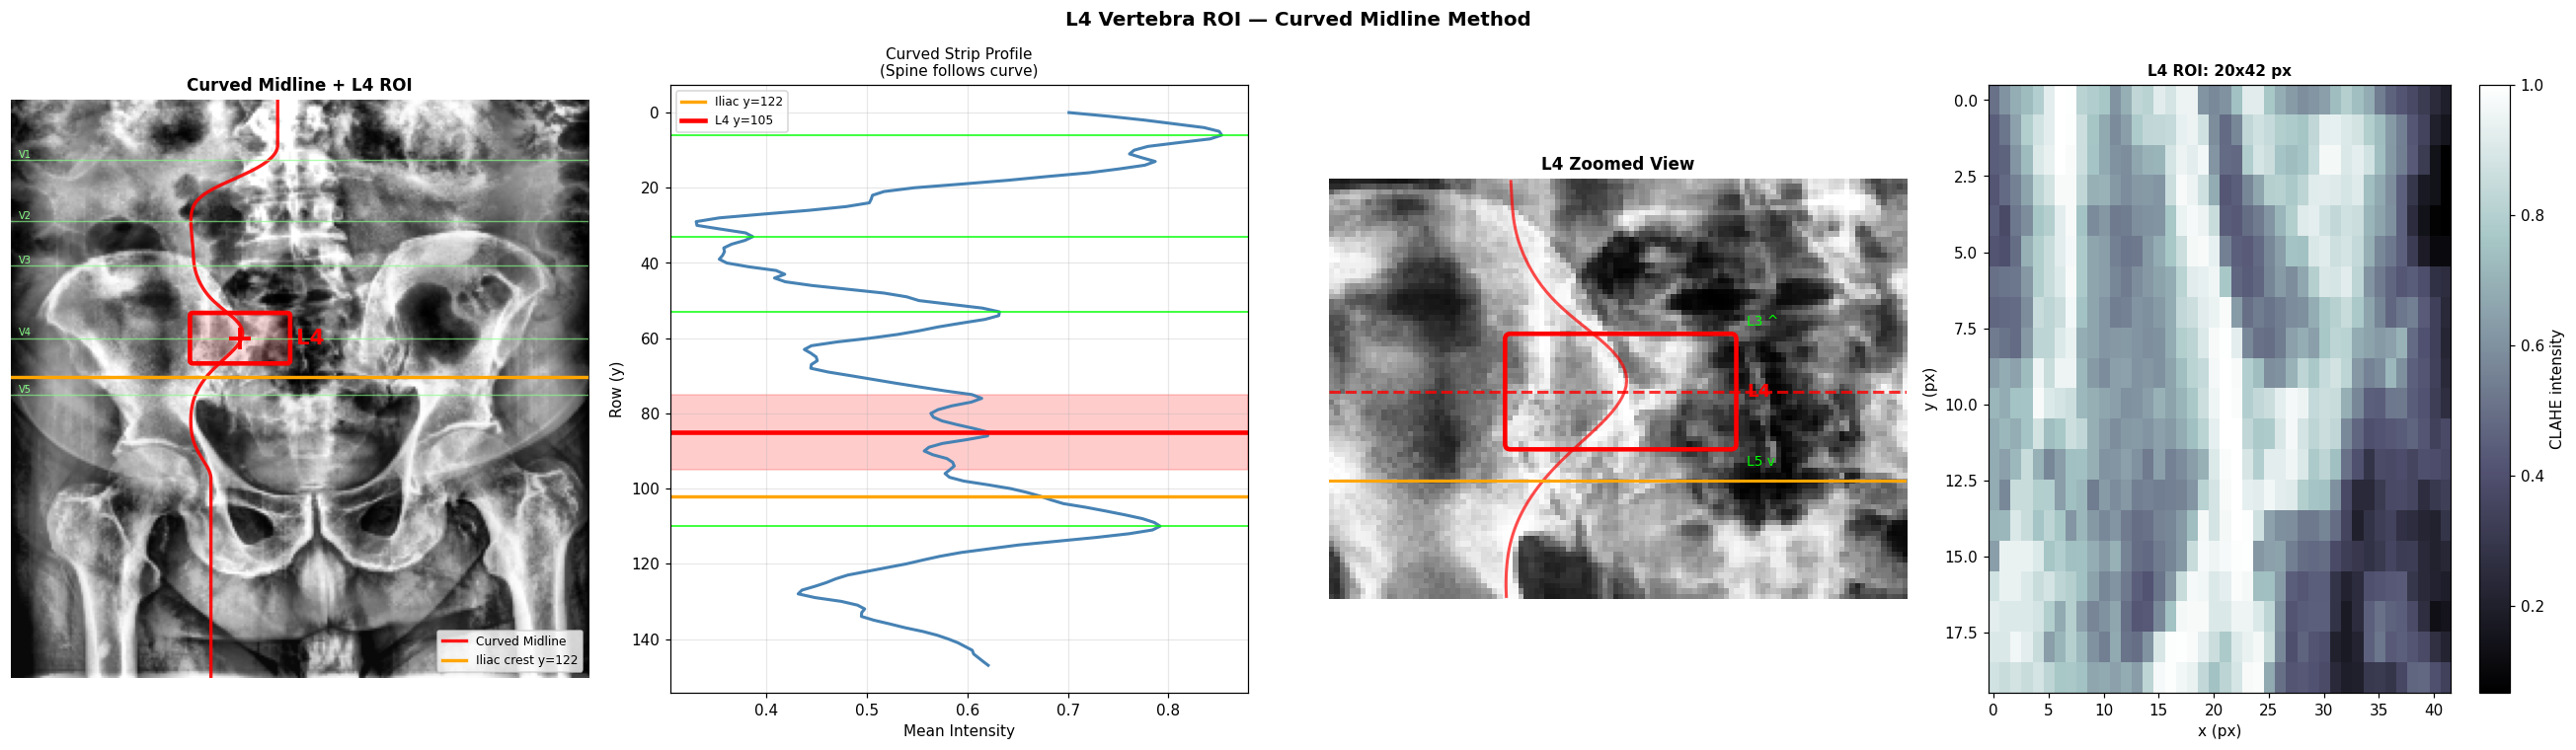

L4 ROI: (20, 42)


In [37]:
def draw_l4_result(clahe, arr_raw, midline_x, iliac_row, peaks_abs,
                   t_l4, l4_row, b_l4, l4_x1, l4_x2,
                   rp_s, r_start, save_path=None):
    h, w = clahe.shape
    fig, axes = plt.subplots(1, 4, figsize=(24, 7))

    # ── 패널 1: 전체 이미지 + Curved Midline ──
    ax = axes[0]
    ax.imshow(clahe, cmap='gray')
    all_rows = np.arange(h)
    ax.plot(midline_x, all_rows, 'r-', lw=2.2, alpha=0.9, label='Curved Midline')
    ax.axhline(iliac_row, color='#FFA500', lw=2.2, label=f'Iliac crest y={iliac_row}')
    for i, p in enumerate(peaks_abs):
        ax.axhline(p, color='#88FF88', lw=0.9, alpha=0.65)
        ax.text(3, p-1, f'V{i+1}', fontsize=6.5, color='#88FF88')
    # L4 ROI (midline-centered)
    rect  = mpatches.FancyBboxPatch((l4_x1,t_l4), l4_x2-l4_x1, b_l4-t_l4,
                boxstyle='round,pad=1.2', lw=3,
                edgecolor='red', facecolor='red', alpha=0.12)
    rect2 = mpatches.FancyBboxPatch((l4_x1,t_l4), l4_x2-l4_x1, b_l4-t_l4,
                boxstyle='round,pad=1.2', lw=3,
                edgecolor='red', facecolor='none')
    ax.add_patch(rect); ax.add_patch(rect2)
    ax.plot(l4_spine_x, l4_row, 'r+', ms=14, mew=2.5, zorder=6)
    ax.text(l4_x2+4, l4_row, 'L4', color='red',
            fontsize=14, fontweight='bold', va='center')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title('Curved Midline + L4 ROI', fontsize=11, fontweight='bold')
    ax.axis('off')

    # ── 패널 2: Curved Strip Profile ──
    ax = axes[1]
    ax.plot(rp_s, range(len(rp_s)), 'steelblue', lw=2)
    for p in peaks_abs:
        ax.axhline(p - r_start, color='lime', lw=1.2, alpha=0.8)
    ax.axhline(iliac_row - r_start, color='#FFA500', lw=2.2,
               label=f'Iliac y={iliac_row}')
    ax.axhline(l4_row - r_start, color='red', lw=3,
               label=f'L4 y={l4_row}')
    ax.axhspan(t_l4 - r_start, b_l4 - r_start, alpha=0.2, color='red')
    ax.invert_yaxis()
    ax.set_xlabel('Mean Intensity'); ax.set_ylabel('Row (y)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title('Curved Strip Profile\n(Spine follows curve)', fontsize=10)

    # ── 패널 3: L4 확대 ──
    zy1 = max(0, t_l4 - 30); zy2 = min(h, b_l4 + 30)
    zx1 = max(0, l4_spine_x - 55); zx2 = min(w, l4_spine_x + 55)
    ax = axes[2]
    ax.imshow(clahe[zy1:zy2, zx1:zx2], cmap='gray')
    rect3 = mpatches.FancyBboxPatch(
        (l4_x1-zx1, t_l4-zy1), l4_x2-l4_x1, b_l4-t_l4,
        boxstyle='round,pad=1', lw=3, edgecolor='red', facecolor='none')
    ax.add_patch(rect3)
    ax.plot(midline_x[zy1:zy2] - zx1, range(zy2-zy1), 'r-', lw=2, alpha=0.7)
    ax.axhline(l4_row-zy1, color='red', lw=2, linestyle='--', alpha=0.8)
    ax.axhline(iliac_row-zy1, color='#FFA500', lw=2)
    ax.text(l4_x2-zx1+3, l4_row-zy1, 'L4', color='red',
            fontsize=12, fontweight='bold', va='center')
    ax.text(l4_x2-zx1+3, t_l4-zy1-2, 'L3 ^', color='lime', fontsize=9, va='bottom')
    ax.text(l4_x2-zx1+3, b_l4-zy1+2, 'L5 v', color='lime', fontsize=9, va='top')
    ax.set_title('L4 Zoomed View', fontsize=11, fontweight='bold'); ax.axis('off')

    # ── 패널 4: L4 ROI ──
    l4_roi = clahe[t_l4:b_l4, l4_x1:l4_x2]
    ax = axes[3]
    im = ax.imshow(l4_roi, cmap='bone', aspect='auto')
    plt.colorbar(im, ax=ax, label='CLAHE intensity')
    ax.set_title(f'L4 ROI: {l4_roi.shape[0]}x{l4_roi.shape[1]} px',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    plt.suptitle('L4 Vertebra ROI — Curved Midline Method',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    return clahe[t_l4:b_l4, l4_x1:l4_x2], clahe[t_l4:b_l4, l4_x1:l4_x2]


l4_roi_clahe, l4_roi_norm = draw_l4_result(
    clahe, arr, midline_x, iliac_row, peaks_abs,
    t_l4, l4_row, b_l4, l4_x1, l4_x2, rp_s, r_start,
    save_path=f'{RESULT_DIR}/03_l4_detection.png'
)
print(f"L4 ROI: {l4_roi_clahe.shape}")


## Step 6: U-Net 척추 세그멘테이션 모델

In [38]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc, drop=0.1):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc,oc,3,padding=1,bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop>0 else nn.Identity())
    def forward(self,x): return self.c(x)


class SpineUNet(nn.Module):
    """
    U-Net 척추 세그멘테이션
    입력:  (B,1,H,W)
    출력:  (B,7,H,W)  — 0:BG, 1:L1, 2:L2, 3:L3, 4:L4, 5:L5, 6:Sacrum

    U-Net 구조를 사용하는 이유:
    - Skip connection → 세밀한 경계 보존
    - Encoder-Decoder → 글로벌 문맥 + 로컬 디테일 동시 학습
    """
    N = 7
    def __init__(self, ic=1, base=32, drop=0.1):
        super().__init__()
        b = base
        self.e1 = DoubleConv(ic, b,   drop); self.p = nn.MaxPool2d(2)
        self.e2 = DoubleConv(b,  b*2, drop)
        self.e3 = DoubleConv(b*2,b*4, drop)
        self.e4 = DoubleConv(b*4,b*8, drop)
        self.bn = DoubleConv(b*8,b*16,drop)
        self.u4 = nn.ConvTranspose2d(b*16,b*8,2,stride=2); self.d4=DoubleConv(b*16,b*8, drop)
        self.u3 = nn.ConvTranspose2d(b*8, b*4,2,stride=2); self.d3=DoubleConv(b*8, b*4, drop)
        self.u2 = nn.ConvTranspose2d(b*4, b*2,2,stride=2); self.d2=DoubleConv(b*4, b*2, drop)
        self.u1 = nn.ConvTranspose2d(b*2, b,  2,stride=2); self.d1=DoubleConv(b*2, b,   drop)
        self.out= nn.Conv2d(b,self.N,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.p(e1)); e3=self.e3(self.p(e2)); e4=self.e4(self.p(e3))
        b =self.bn(self.p(e4))
        d4=self.d4(torch.cat([self.u4(b), e4],1))
        d3=self.d3(torch.cat([self.u3(d4),e3],1))
        d2=self.d2(torch.cat([self.u2(d3),e2],1))
        d1=self.d1(torch.cat([self.u1(d2),e1],1))
        return self.out(d1)

unet = SpineUNet().to(DEVICE)
print(f"SpineUNet params: {sum(p.numel() for p in unet.parameters()):,}")
_x = torch.randn(1,1,256,256).to(DEVICE)
print(f"Forward: {_x.shape} -> {unet(_x).shape}")


SpineUNet params: 7,762,663
Forward: torch.Size([1, 1, 256, 256]) -> torch.Size([1, 7, 256, 256])


## Step 7: BMD 회귀 모델 (ResNet-18)

In [39]:
class BMDRegressor(nn.Module):
    """
    ResNet-18 backbone → T-Score 회귀
    입력: (B,1,roi_size,roi_size)  출력: (B,1)
    """
    def __init__(self):
        super().__init__()
        bb = models.resnet18(weights=None)
        bb.conv1 = nn.Conv2d(1,64,7,stride=2,padding=3,bias=False)
        nf       = bb.fc.in_features
        bb.fc    = nn.Identity()
        self.bb  = bb
        self.head= nn.Sequential(
            nn.Linear(nf,256), nn.ReLU(), nn.Dropout(0.35),
            nn.Linear(256,64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,1))
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self,x): return self.head(self.bb(x))

bmd_model = BMDRegressor().to(DEVICE)
print(f"BMDRegressor params: {sum(p.numel() for p in bmd_model.parameters()):,}")
_x2 = torch.randn(2,1,64,64).to(DEVICE)
print(f"Forward: {_x2.shape} -> {bmd_model(_x2).shape}")


BMDRegressor params: 11,318,081
Forward: torch.Size([2, 1, 64, 64]) -> torch.Size([2, 1])


## Step 8: Dataset & DataLoader

In [40]:
def full_pipeline(path, cfg=CFG):
    """DICOM → L4 ROI 완전 파이프라인"""
    r = {'status':'OK','filename':os.path.basename(path)}
    try:
        arr_d, meta, _ = load_dicom(path)
        norm_d, clahe_d = preprocess_xray(arr_d, cfg['img_size'])
        h_d, w_d = clahe_d.shape

        ml_x, _         = detect_curved_midline(clahe_d, cfg)
        p_abs, tr_abs, rp, rs = detect_vertebrae_curved(clahe_d, ml_x, cfg)
        iliac_r         = detect_iliac_crest(clahe_d, cfg)
        l4r,l4sx,tl4,bl4,l4x1,l4x2 = localize_l4(p_abs,tr_abs,iliac_r,h_d,ml_x,w_d,cfg)

        r.update({'meta':meta,'norm':norm_d,'clahe':clahe_d,
                  'midline_x':ml_x,'iliac_row':iliac_r,
                  'peaks_abs':p_abs,'troughs_abs':tr_abs,'rp_s':rp,'r_start':rs,
                  'l4_row':l4r,'l4_spine_x':l4sx,
                  't_l4':tl4,'b_l4':bl4,'l4_x1':l4x1,'l4_x2':l4x2,
                  'l4_roi': clahe_d[tl4:bl4,l4x1:l4x2]})
    except Exception as e:
        r['status'] = f'ERROR: {e}'
    return r


class SpineDICOMDataset(Dataset):
    """
    DICOM Dataset (curved midline pipeline)
    레이블 없으면 pixel proxy T-score 자동 계산
    """
    def __init__(self, paths, label_df=None, augment=False, cfg=CFG):
        self.paths   = paths
        self.augment = augment
        self.cfg     = cfg
        self.labels  = {}
        if label_df is not None:
            for _, row in label_df.iterrows():
                self.labels[row['filename']] = float(row['t_score'])

    def __len__(self): return len(self.paths)

    def _proxy(self, roi):
        flat = roi.ravel()
        lo,hi = np.percentile(flat,[10,90])
        core  = flat[(flat>=lo)&(flat<=hi)]
        tm    = float(np.mean(core)) if len(core)>0 else float(flat.mean())
        return float(np.clip((tm - self.cfg['ref_young_mean'])/self.cfg['ref_young_std'],-5,2))

    def _aug(self, roi):
        if np.random.rand()<0.5: roi=np.fliplr(roi).copy()
        angle = np.random.uniform(-5,5)
        hh,ww = roi.shape
        M = cv2.getRotationMatrix2D((ww/2,hh/2),angle,1.0)
        roi = cv2.warpAffine(roi,M,(ww,hh),borderMode=cv2.BORDER_REFLECT)
        return np.clip(roi*np.random.uniform(0.9,1.1),0,1).astype(np.float32)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        fname = os.path.basename(path)
        try:
            res = full_pipeline(path, self.cfg)
            roi = res['l4_roi'].astype(np.float32) if res['status']=='OK' else                   np.zeros((self.cfg['roi_size'],self.cfg['roi_size']),dtype=np.float32)
            if roi.size==0 or min(roi.shape)<4:
                roi = np.zeros((self.cfg['roi_size'],self.cfg['roi_size']),dtype=np.float32)
            roi = cv2.resize(roi,(self.cfg['roi_size'],self.cfg['roi_size']))
            if self.augment: roi = self._aug(roi)
            ts  = self.labels.get(fname, self._proxy(roi))
        except:
            roi = np.zeros((self.cfg['roi_size'],self.cfg['roi_size']),dtype=np.float32)
            ts  = 0.0
        return {'roi'  : torch.FloatTensor(roi).unsqueeze(0),
                'label': torch.FloatTensor([ts]),
                'fname': fname}


def build_dataloaders(root, label_csv=None, cfg=CFG):
    ldf = pd.read_csv(label_csv) if (label_csv and os.path.exists(label_csv)) else None
    if ldf is not None: print(f"Labels: {len(ldf)}")

    def gdcm(d):
        return list(set(
            glob.glob(os.path.join(d,'*.dcm'))+
            glob.glob(os.path.join(d,'*.DCM'))+
            glob.glob(os.path.join(d,'**','*.dcm'),recursive=True)))

    tr=gdcm(os.path.join(root,'train'))
    va=gdcm(os.path.join(root,'val'))
    te=gdcm(os.path.join(root,'test'))

    if not tr:
        all_f = gdcm(root)
        if not all_f: print(f"No DICOM in {root}"); return None,None,None
        np.random.seed(42); idx=np.random.permutation(len(all_f))
        ntr=int(len(idx)*cfg['train_ratio']); nva=int(len(idx)*cfg['val_ratio'])
        tr=[all_f[i] for i in idx[:ntr]]
        va=[all_f[i] for i in idx[ntr:ntr+nva]]
        te=[all_f[i] for i in idx[ntr+nva:]]
    print(f"Train={len(tr)}, Val={len(va)}, Test={len(te)}")

    mk = lambda p,aug: DataLoader(SpineDICOMDataset(p,ldf,aug,cfg),
                                   batch_size=cfg['batch_size'],
                                   shuffle=aug, num_workers=0)
    return mk(tr,True), mk(va,False), DataLoader(
        SpineDICOMDataset(te,ldf,False,cfg), batch_size=1, shuffle=False, num_workers=0)

print("Dataset classes ready")


Dataset classes ready


## Step 9: Train / Validation / Test

In [41]:
def train_model(model, dl_tr, dl_va, cfg=CFG, save_path=None):
    opt  = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['num_epochs'], eta_min=1e-6)
    loss_fn = nn.HuberLoss(delta=0.5)
    hist = {'train':[], 'val':[], 'mae':[]}
    best, pat = float('inf'), 0

    for ep in range(1, cfg['num_epochs']+1):
        model.train()
        tr_l = 0.0
        for b in tqdm(dl_tr, desc=f'Ep{ep:3d} Train', leave=False, ncols=70):
            opt.zero_grad()
            pred = model(b['roi'].to(DEVICE))
            loss = loss_fn(pred, b['label'].to(DEVICE))
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            tr_l += loss.item()
        tr_l /= max(len(dl_tr),1); sch.step()

        model.eval(); va_l=0.0; va_mae=0.0
        with torch.no_grad():
            for b in dl_va:
                p = model(b['roi'].to(DEVICE)); lab = b['label'].to(DEVICE)
                va_l   += loss_fn(p, lab).item()
                va_mae += torch.abs(p-lab).mean().item()
        va_l /= max(len(dl_va),1); va_mae /= max(len(dl_va),1)

        hist['train'].append(tr_l); hist['val'].append(va_l); hist['mae'].append(va_mae)

        if va_l < best:
            best=va_l; pat=0
            if save_path: torch.save(model.state_dict(), save_path)
            print(f"Ep{ep:3d} | tr={tr_l:.4f} val={va_l:.4f} MAE={va_mae:.3f} [saved]")
        else:
            pat += 1
            if ep%5==0: print(f"Ep{ep:3d} | tr={tr_l:.4f} val={va_l:.4f} MAE={va_mae:.3f} patience={pat}")
            if pat >= cfg['early_stop']: print(f"Early stop @ ep{ep}"); break

    return hist


def evaluate_model(model, dl_te, ckpt=None):
    if ckpt and os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE)); print(f"Loaded: {ckpt}")
    model.eval()
    preds,labels,fnames=[],[],[]
    with torch.no_grad():
        for b in dl_te:
            preds.extend(model(b['roi'].to(DEVICE)).cpu().numpy().flatten())
            labels.extend(b['label'].numpy().flatten())
            fnames.extend(b['fname'])
    preds=np.array(preds); labels=np.array(labels)
    mae =np.mean(np.abs(preds-labels))
    rmse=np.sqrt(np.mean((preds-labels)**2))
    print(f"Test n={len(preds)} | MAE={mae:.3f} | RMSE={rmse:.3f}")
    return {'preds':preds,'labels':labels,'fnames':fnames,'mae':mae,'rmse':rmse}


# ── 훈련 실행 ──
RUN = os.path.exists(DATASET_ROOT) and len(
    glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True))>0
print(f"Dataset found: {RUN}")

if RUN:
    CKPT = f'{MODEL_DIR}/best_bmd.pth'
    dl_tr, dl_va, dl_te = build_dataloaders(DATASET_ROOT, LABEL_CSV, CFG)
    if dl_tr:
        hist = train_model(bmd_model, dl_tr, dl_va, CFG, CKPT)
        # 학습 곡선
        fig,axes=plt.subplots(1,2,figsize=(12,4))
        ep=range(1,len(hist['train'])+1)
        axes[0].plot(ep,hist['train'],label='Train'); axes[0].plot(ep,hist['val'],label='Val')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(ep,hist['mae'],color='green'); axes[1].set_title('Val MAE'); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.savefig(f'{RESULT_DIR}/training.png',dpi=120); plt.show()
        evaluate_model(bmd_model, dl_te, CKPT)
else:
    print("No dataset — running single-file inference mode")


Dataset found: False
No dataset — running single-file inference mode


## Step 10: BMD 측정 & WHO T-Score

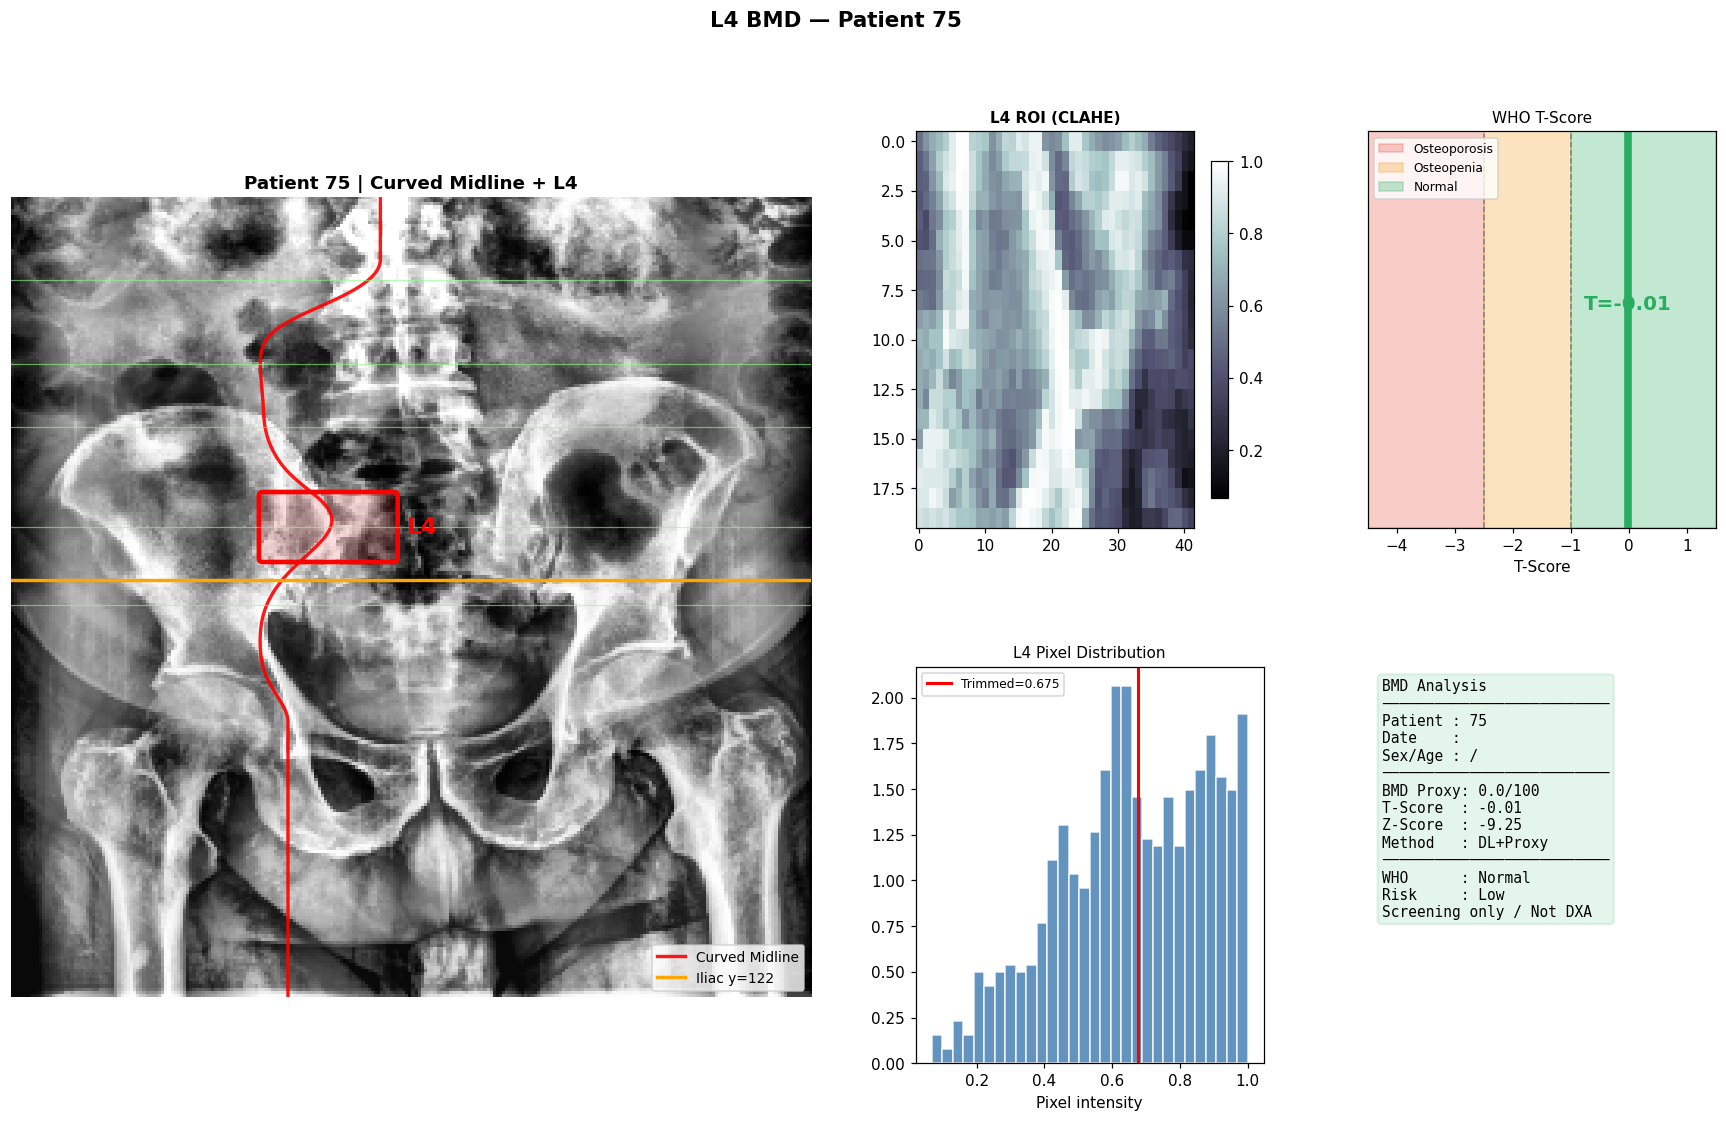


T-Score: -0.01 | Normal | Risk: Low


In [42]:
def estimate_bmd(roi_raw, model=None, cfg=CFG):
    if roi_raw is None or roi_raw.size==0: return None
    flat=roi_raw.ravel(); lo,hi=np.percentile(flat,[10,90])
    core=flat[(flat>=lo)&(flat<=hi)]; tm=float(np.mean(core)) if len(core)>0 else flat.mean()

    # DL 모델
    ts_dl = None
    if model is not None:
        model.eval()
        r64 = cv2.resize(roi_raw.astype(np.float32),(cfg['roi_size'],cfg['roi_size']))
        with torch.no_grad():
            ts_dl=float(model(torch.FloatTensor(r64).unsqueeze(0).unsqueeze(0).to(DEVICE)).cpu().item())

    ts_proxy = (tm - cfg['ref_young_mean']) / cfg['ref_young_std']
    zs       = (tm - cfg['ref_age_mean'])   / cfg['ref_age_std']
    bmd_p    = float(np.clip((tm/cfg['ref_young_mean'])*100,0,130))
    ts_final = ts_dl if ts_dl is not None else ts_proxy

    if   ts_final >= -1.0: who,risk,col="Normal",               "Low",     "#27ae60"
    elif ts_final >= -2.5: who,risk,col="Osteopenia",           "Moderate","#e67e22"
    else:                  who,risk,col="Osteoporosis",          "High",    "#e74c3c"

    return {'tm':tm,'bmd_proxy':bmd_p,
            'ts_proxy':ts_proxy,'ts_dl':ts_dl,'ts_final':ts_final,'zs':zs,
            'who':who,'risk':risk,'color':col,
            'method':'DL+Proxy' if ts_dl else 'Proxy'}


# ── 샘플 파일 측정 ──
res = full_pipeline(DICOM_FILE)
if res['status']=='OK':
    bmd = estimate_bmd(res['l4_roi'], bmd_model)

    fig = plt.figure(figsize=(20,11))
    gs  = GridSpec(2,4,figure=fig,hspace=0.35,wspace=0.30)

    # 전체 X-ray + Curved Midline
    ax = fig.add_subplot(gs[:,0:2])
    cl=res['clahe']; ml=res['midline_x']; h_r,w_r=cl.shape
    ax.imshow(cl,cmap='gray')
    ax.plot(ml, np.arange(h_r), 'r-', lw=2.2, alpha=0.9, label='Curved Midline')
    ax.axhline(res['iliac_row'],color='#FFA500',lw=2.2,label=f"Iliac y={res['iliac_row']}")
    for p in res['peaks_abs']:
        ax.axhline(p,color='#88FF88',lw=0.8,alpha=0.6)
    rect=mpatches.FancyBboxPatch((res['l4_x1'],res['t_l4']),
         res['l4_x2']-res['l4_x1'],res['b_l4']-res['t_l4'],
         boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='red',alpha=0.12)
    rect2=mpatches.FancyBboxPatch((res['l4_x1'],res['t_l4']),
          res['l4_x2']-res['l4_x1'],res['b_l4']-res['t_l4'],
          boxstyle='round,pad=1.2',lw=3,edgecolor='red',facecolor='none')
    ax.add_patch(rect); ax.add_patch(rect2)
    ax.text(res['l4_x2']+4,res['l4_row'],'L4',color='red',fontsize=15,fontweight='bold',va='center')
    ax.legend(fontsize=9,loc='lower right')
    ax.set_title(f"Patient {res['meta']['patient_id']} | Curved Midline + L4",
                 fontsize=12,fontweight='bold'); ax.axis('off')

    # L4 ROI
    ax=fig.add_subplot(gs[0,2])
    im=ax.imshow(res['l4_roi'],cmap='bone',aspect='auto')
    plt.colorbar(im,ax=ax,shrink=0.85)
    ax.set_title('L4 ROI (CLAHE)',fontsize=10,fontweight='bold')

    # 히스토그램
    ax=fig.add_subplot(gs[1,2])
    flat=res['l4_roi'].ravel()
    ax.hist(flat,bins=30,color='steelblue',edgecolor='white',alpha=0.85,density=True)
    ax.axvline(bmd['tm'],color='red',lw=2,label=f"Trimmed={bmd['tm']:.3f}")
    ax.legend(fontsize=8); ax.set_xlabel('Pixel intensity')
    ax.set_title('L4 Pixel Distribution',fontsize=10)

    # T-Score 게이지
    ax=fig.add_subplot(gs[0,3]); t=bmd['ts_final']
    ax.set_xlim(-4.5,1.5); ax.set_ylim(0,1)
    ax.axvspan(-4.5,-2.5,color='#e74c3c',alpha=0.28,label='Osteoporosis')
    ax.axvspan(-2.5,-1.0,color='#f39c12',alpha=0.28,label='Osteopenia')
    ax.axvspan(-1.0, 1.5,color='#27ae60',alpha=0.28,label='Normal')
    ax.axvline(t,color=bmd['color'],lw=5)
    ax.axvline(-2.5,color='gray',lw=1,linestyle='--'); ax.axvline(-1.0,color='gray',lw=1,linestyle='--')
    ax.text(t,0.55,f'T={t:+.2f}',color=bmd['color'],fontsize=13,fontweight='bold',ha='center')
    ax.set_xlabel('T-Score'); ax.set_yticks([]); ax.legend(fontsize=8,loc='upper left')
    ax.set_title('WHO T-Score',fontsize=10)

    # 요약
    ax=fig.add_subplot(gs[1,3]); ax.axis('off')
    m=res['meta']
    summary=(f"BMD Analysis\n"
             f"{'─'*26}\n"
             f"Patient : {m['patient_id']}\n"
             f"Date    : {m['study_date']}\n"
             f"Sex/Age : {m['patient_sex']}/{m['patient_age']}\n"
             f"{'─'*26}\n"
             f"BMD Proxy: {bmd['bmd_proxy']:.1f}/100\n"
             f"T-Score  : {bmd['ts_final']:+.2f}\n"
             f"Z-Score  : {bmd['zs']:+.2f}\n"
             f"Method   : {bmd['method']}\n"
             f"{'─'*26}\n"
             f"WHO      : {bmd['who']}\n"
             f"Risk     : {bmd['risk']}\n"
             f"Screening only / Not DXA")
    ax.text(0.04,0.97,summary,transform=ax.transAxes,fontsize=9.5,va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round',facecolor=bmd['color'],alpha=0.12,edgecolor=bmd['color'],lw=1.5))

    plt.suptitle(f"L4 BMD — Patient {m['patient_id']}",fontsize=14,fontweight='bold')
    plt.savefig(f'{RESULT_DIR}/04_bmd_dashboard.png',dpi=130,bbox_inches='tight')
    plt.show()

    print(f"\nT-Score: {bmd['ts_final']:+.2f} | {bmd['who']} | Risk: {bmd['risk']}")


## Step 11: 배치 처리 & CSV 리포트

In [43]:
def run_batch(paths, model=None, save_dir=None):
    if save_dir: os.makedirs(save_dir, exist_ok=True)
    rows=[]
    for i,p in enumerate(tqdm(paths,desc='Batch',ncols=70)):
        r=full_pipeline(p)
        row={'idx':i+1,'filename':os.path.basename(p),'status':r['status']}
        if r['status']=='OK':
            bmd=estimate_bmd(r['l4_roi'],model)
            if bmd:
                m=r['meta']
                row.update({
                    'patient_id':m['patient_id'],'study_date':m['study_date'],
                    'l4_row':r['l4_row'],'l4_spine_x':r['l4_spine_x'],
                    'l4_bbox':f"y={r['t_l4']}:{r['b_l4']},x={r['l4_x1']}:{r['l4_x2']}",
                    'bmd_proxy':f"{bmd['bmd_proxy']:.1f}",
                    't_score':f"{bmd['ts_final']:+.3f}",
                    'z_score':f"{bmd['zs']:+.3f}",
                    'who':bmd['who'],'risk':bmd['risk'],'method':bmd['method']})
        rows.append(row)

    df=pd.DataFrame(rows)
    csv_p=os.path.join(save_dir or '.','bmd_batch.csv')
    df.to_csv(csv_p,index=False)
    ok=df[df['status']=='OK']
    print(f"\nBatch done: {len(rows)} | OK: {len(ok)}")
    if len(ok)>0 and 't_score' in ok.columns:
        ts=ok['t_score'].astype(float)
        print(f"T-Score: mean={ts.mean():+.2f} min={ts.min():+.2f} max={ts.max():+.2f}")
    return df

# 실행
files = (glob.glob('./*.dcm')+glob.glob('./*.DCM')+
         glob.glob(os.path.join(DATASET_ROOT,'**','*.dcm'),recursive=True))
files = list(set(files))[:30]

if files:
    df = run_batch(files, bmd_model, save_dir=f'{RESULT_DIR}/batch')
    print(df[['filename','t_score','who','risk']].to_string())
else:
    df = run_batch([DICOM_FILE], bmd_model, save_dir=f'{RESULT_DIR}/batch')
    print(df.to_string())


Batch: 100%|████████████████████████████| 1/1 [00:00<00:00, 34.85it/s]


Batch done: 1 | OK: 1
T-Score: mean=-0.01 min=-0.01 max=-0.01
   idx                                                                filename status patient_id study_date  l4_row  l4_spine_x            l4_bbox bmd_proxy t_score z_score     who risk    method
0    1  1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm     OK         75                105         101  y=95:115,x=80:122       0.0  -0.013  -9.250  Normal  Low  DL+Proxy


## 부록: 데이터셋 구조 & 개선 포인트

### 데이터셋 폴더 구조
```
dataset/
├── train/*.dcm     ← 훈련 DICOM
├── val/*.dcm       ← 검증
├── test/*.dcm      ← 테스트
└── labels.csv      ← (선택) filename, t_score
```

### Curved Midline 핵심 파라미터 튜닝
| 파라미터 | 기본값 | 효과 |
|---|---|---|
| `midline_max_step` | 5 | 작을수록 직선에 가까워짐, 크면 더 많이 굽을 수 있음 |
| `midline_sigma`    | 6.0 | 클수록 부드러운 곡선, 작으면 노이즈 민감 |
| `midline_window_w` | 16 | 크면 soft peak 탐지, 작으면 sharp |

### 정확도 향상 방법
1. VerSe 데이터셋 기반 pretrained U-Net 활용 (CT 기반이지만 transfer 가능)
2. 척추체 마스크 레이블 → U-Net fine-tuning
3. Phantom 스캔 기반 BMD calibration
